<a href="https://colab.research.google.com/github/ismichairunisa/PBO/blob/main/Praktikum_Klasifikasi_Citra_Buah_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PRAKTIKUM BIG DATA ANALITIK
# Klasifikasi Citra Buah Apel, Pisang, dan Jeruk Menggunakan CNN
# Platform: Google colab

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import tensorflow as tf
from tensorflow.keras import layers, models

# Agar hasil percobaan lebih konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# 1. MEMBUAT DATASET CITRA BUAH SECARA OTOMATIS


IMG_SIZE = 128
JUMLAH_GAMBAR_PER_KELAS = 120
BASE_DIR = "/content/dataset_buah"
KELAS_BUAH = ["apel", "pisang", "jeruk"]

# Hapus dataset lama jika ada
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for nama_kelas in KELAS_BUAH:
    os.makedirs(os.path.join(BASE_DIR, nama_kelas), exist_ok=True)

def tambah_noise(img, level=8):
    """Menambahkan sedikit noise agar data tidak terlalu polos."""
    arr = np.array(img).astype(np.int16)
    noise = np.random.randint(-level, level + 1, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def buat_background():
    """Membuat background berwarna terang."""
    warna = tuple(np.random.randint(225, 256, size=3).tolist())
    return Image.new("RGB", (IMG_SIZE, IMG_SIZE), warna)

def gambar_apel():
    img = buat_background()
    draw = ImageDraw.Draw(img)
    x = random.randint(26, 38)
    y = random.randint(30, 42)
    w = random.randint(55, 70)
    h = random.randint(58, 75)

    warna_apel = (random.randint(190, 255), random.randint(10, 60), random.randint(10, 60))

    # Menggambar bentuk apel, tangkai, daun, dan highlight kilauan lampu
    draw.ellipse((x, y, x + w, y + h), fill=warna_apel, outline=(120, 0, 0), width=2)
    draw.rectangle((x + w//2 - 3, y - 12, x + w//2 + 3, y + 5), fill=(110, 65, 25))
    draw.ellipse((x + w//2 + 4, y - 15, x + w//2 + 25, y + 2), fill=(40, 150, 40))
    draw.ellipse((x + 15, y + 12, x + 30, y + 27), fill=(255, 180, 180))

    return tambah_noise(img)

def gambar_jeruk():
    img = buat_background()
    draw = ImageDraw.Draw(img)
    x = random.randint(26, 38)
    y = random.randint(28, 40)
    ukuran = random.randint(58, 72)

    warna_jeruk = (255, random.randint(120, 180), random.randint(0, 40))
    draw.ellipse((x, y, x + ukuran, y + ukuran), fill=warna_jeruk, outline=(180, 90, 0), width=2)

    # Titik-titik kecil pada jeruk
    for _ in range(18):
        px = random.randint(x + 10, x + ukuran - 10)
        py = random.randint(y + 10, y + ukuran - 10)
        draw.ellipse((px, py, px + 2, py + 2), fill=(230, 110, 0))

    draw.ellipse((x + 14, y + 12, x + 30, y + 28), fill=(255, 210, 120))
    return tambah_noise(img)

def gambar_pisang():
    img = buat_background()
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)
    warna_pisang = (255, random.randint(210, 240), random.randint(20, 70), 255)

    # Membuat bentuk pisang dengan garis lengkung tebal
    draw.arc((15, 20, 116, 118), start=205, end=340, fill=warna_pisang, width=24)
    draw.arc((15, 20, 116, 118), start=205, end=340, fill=(170, 120, 20, 255), width=3)
    draw.ellipse((31, 83, 42, 94), fill=(90, 55, 20, 255))
    draw.ellipse((91, 46, 101, 57), fill=(90, 55, 20, 255))

    sudut = random.randint(-25, 25)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)
    img = Image.alpha_composite(img.convert("RGBA"), layer).convert("RGB")
    return tambah_noise(img)

fungsi_gambar = {
    "apel": gambar_apel,
    "pisang": gambar_pisang,
    "jeruk": gambar_jeruk
}

for nama_kelas in KELAS_BUAH:
    for i in range(JUMLAH_GAMBAR_PER_KELAS):
        img = fungsi_gambar[nama_kelas]()
        path = os.path.join(BASE_DIR, nama_kelas, f"{nama_kelas}_{i:03d}.png")
        img.save(path)

print("Dataset berhasil dibuat di:", BASE_DIR)
print("Jumlah kelas:", len(KELAS_BUAH))
print("Jumlah total gambar:", len(KELAS_BUAH) * JUMLAH_GAMBAR_PER_KELAS)


Dataset berhasil dibuat di: /content/dataset_buah
Jumlah kelas: 3
Jumlah total gambar: 360


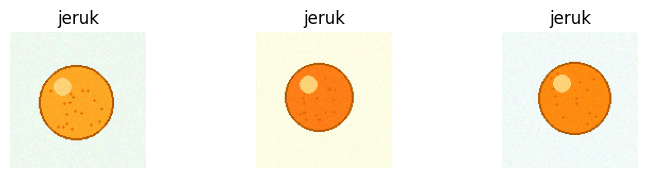

In [ ]:
# MENAMPILKAN CONTOH CITRA DATASET

plt.figure(figsize=(9, 6))
nomor = 1
for nama_kelas in KELAS_BUAH:
  folder = os.path.join(BASE_DIR, nama_kelas)
  contoh_file = random.sample(os.listdir(folder), 3)

 # Perhatikan perpindahan posisi 'for' di bawah ini (menjorok 4 spasi)
for file in contoh_file:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)

        # Sisa kode matplotlib Anda diletakkan di bawah sini (menjorok 8 spasi)
        plt.subplot(3, 3, nomor)
        plt.imshow(img)
        plt.title(nama_kelas)
        plt.axis("off")
        nomor += 1

In [ ]:
# 3. MEMBAGI DATASET MENJADI DATA TRAINING DAN VALIDASI

BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Nama kelas:", class_names)

# Optimasi pembacaan data agar training lebih cepat
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 360 files belonging to 3 classes.
Using 288 files for training.
Found 360 files belonging to 3 classes.
Using 72 files for validation.
Nama kelas: ['apel', 'jeruk', 'pisang']


In [ ]:
# 4. MEMBUAT MODEL CNN SEDERHANA

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08)
])

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,659 (3.15 MB)

 Trainable params: 826,659 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. MELATIH MODEL

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.8438 - loss: 0.3846 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.9896 - loss: 0.0296 - val_accuracy: 0.9306 - val_loss: 0.2200
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.9965 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 4.2965e-04
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 1.0000 - loss: 4.8846e-04 - val_accuracy: 1.0000 - val_loss: 1.6006e-04
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 1.0000 - loss: 2.6797e-04 - val_accuracy: 1.0000 - val_loss: 9.5904e-05
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 1.0000 - loss: 1.3758e-04 - val_accuracy: 1.0000 - val_loss: 5.2620e-05
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 1.0000 - loss: 6.1710e-05 - val_accuracy: 1.0000 - val_loss: 3.3288e-05
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 1.00

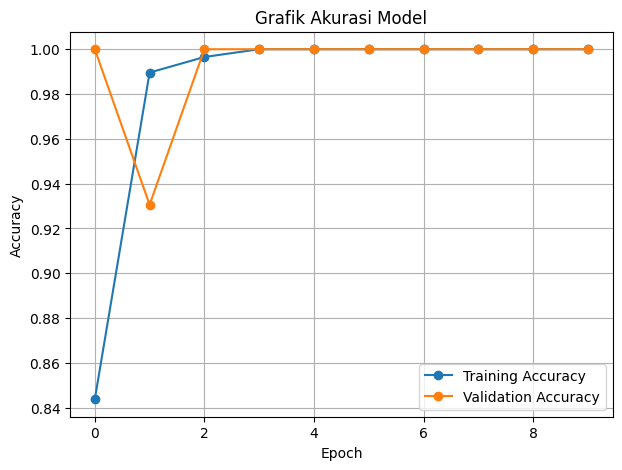

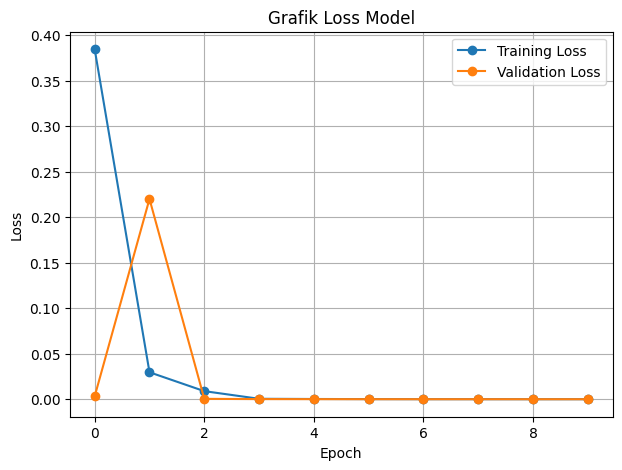

In [ ]:
# 6. MENAMPILKAN GRAFIK AKURASI DAN LOSS

# Grafik Akurasi
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Grafik Akurasi Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Grafik Loss
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Grafik Loss Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# EVALUASI MODEL

loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", round(loss, 4))
print("Validation Accuracy:", round(accuracy, 4))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 1.2638e-05
Validation Loss: 0.0
Validation Accuracy: 1.0


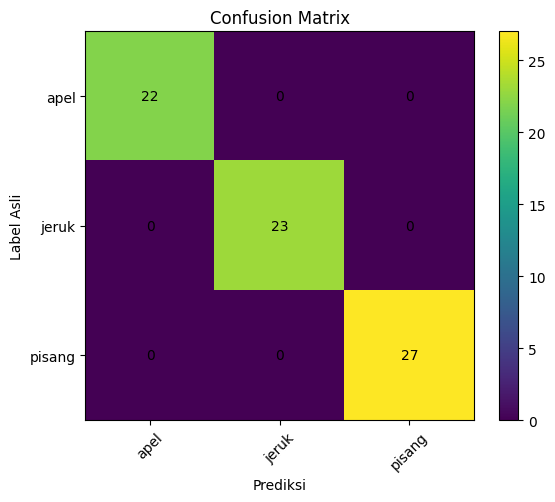

In [ ]:
# MEMBUAT CONFUSION MATRIX

y_true = []
y_pred = []

for gambar, label in val_ds:
    prediksi = model.predict(gambar, verbose=0)
    y_true.extend(label.numpy())
    y_pred.extend(np.argmax(prediksi, axis=1))

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# Menambahkan teks angka di dalam kotak matriks
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

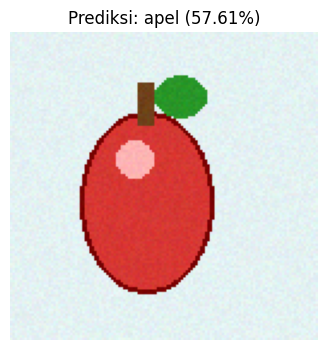

File gambar: /content/dataset_buah/apel/apel_001.png
Hasil prediksi: apel
Confidence: 57.61%


In [ ]:
# 9. PREDIKSI SATU GAMBAR

def prediksi_gambar(gambar_path):
    img = tf.keras.utils.load_img(gambar_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    hasil = model.predict(img_array, verbose=0)
    skor = tf.nn.softmax(hasil[0]).numpy()

    index_tertinggi = np.argmax(skor)
    label_prediksi = class_names[index_tertinggi]
    confidence = 100 * np.max(skor)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {label_prediksi} ({confidence:.2f}%)")
    plt.show()

    print("File gambar:", gambar_path)
    print("Hasil prediksi:", label_prediksi)
    print("Confidence:", f"{confidence:.2f}%")

# Contoh uji menggunakan salah satu gambar dari dataset
contoh_path = os.path.join(BASE_DIR, "apel", "apel_001.png")
prediksi_gambar(contoh_path)

Saving images.jpeg to images.jpeg


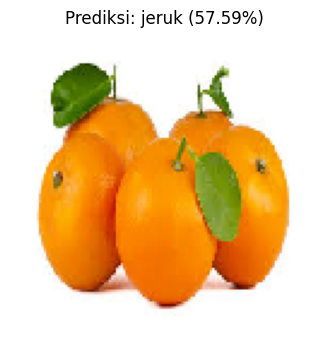

File gambar: images.jpeg
Hasil prediksi: jeruk
Confidence: 57.59%


In [ ]:
# 10. OPSIONAL : UPLOAD GAMBAR DARI KOMPUTER MAHASISWA

from google.colab import files

uploaded = files.upload()
for nama_file in uploaded.keys():
    prediksi_gambar(nama_file)

TensorFlow version: 2.20.0
Dataset berhasil dibuat di: /content/dataset_buah
Jumlah kelas: 3
Jumlah total gambar: 360


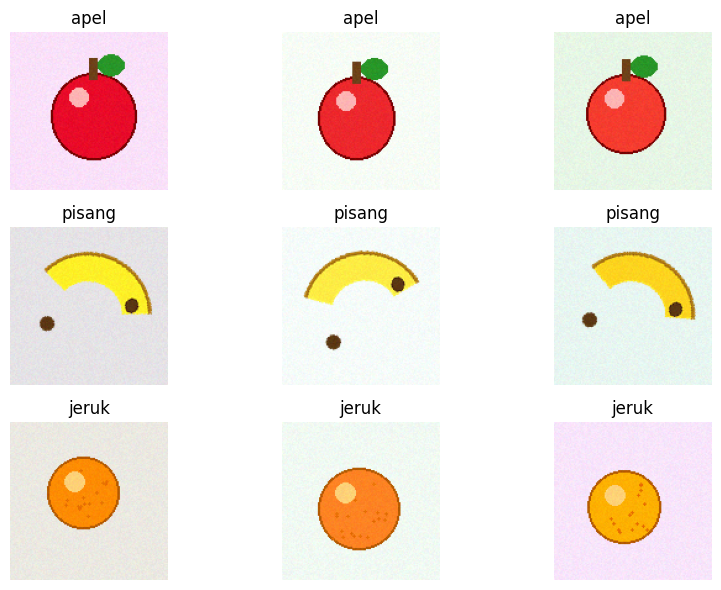

In [ ]:
# 11. MENYIMPAN MODEL

# =====================================================================
# 6.2 Kode Bagian 1 & 2: INSTALASI, IMPORT, DAN PENYIAPAN DIREKTORI
# =====================================================================

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import tensorflow as tf
from tensorflow.keras import layers, models

# Agar hasil percobaan lebih konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

# PROSES PEMBUATAN DATASET CITRA BUAH SECARA OTOMATIS
IMG_SIZE = 128
JUMLAH_GAMBAR_PER_KELAS = 120
BASE_DIR = "/content/dataset_buah"
KELAS_BUAH = ["apel", "pisang", "jeruk"]

# Hapus dataset lama jika ada
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for nama_kelas in KELAS_BUAH:
    os.makedirs(os.path.join(BASE_DIR, nama_kelas), exist_ok=True)


# =====================================================================
# FUNGSI GENERATOR GAMBAR (APEL, JERUK, PISANG)
# =====================================================================

def tambah_noise(img, level=8):
    """Menambahkan sedikit noise agar data tidak terlalu polos."""
    arr = np.array(img).astype(np.int16)
    noise = np.random.randint(-level, level + 1, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def buat_background():
    """Membuat background berwarna terang."""
    warna = tuple(np.random.randint(225, 256, size=3).tolist())
    return Image.new("RGB", (IMG_SIZE, IMG_SIZE), warna)

def gambar_apel():
    img = buat_background()
    draw = ImageDraw.Draw(img)
    x = random.randint(26, 38)
    y = random.randint(30, 42)
    w = random.randint(55, 70)
    h = random.randint(58, 75)

    warna_apel = (random.randint(190, 255), random.randint(10, 60), random.randint(10, 60))

    # Menggambar bentuk apel, tangkai, daun, dan highlight kilauan lampu
    draw.ellipse((x, y, x + w, y + h), fill=warna_apel, outline=(120, 0, 0), width=2)
    draw.rectangle((x + w//2 - 3, y - 12, x + w//2 + 3, y + 5), fill=(110, 65, 25))
    draw.ellipse((x + w//2 + 4, y - 15, x + w//2 + 25, y + 2), fill=(40, 150, 40))
    draw.ellipse((x + 15, y + 12, x + 30, y + 27), fill=(255, 180, 180))
    return tambah_noise(img)

def gambar_jeruk():
    img = buat_background()
    draw = ImageDraw.Draw(img)
    x = random.randint(26, 38)
    y = random.randint(28, 40)
    ukuran = random.randint(58, 72)

    warna_jeruk = (255, random.randint(120, 180), random.randint(0, 40))
    draw.ellipse((x, y, x + ukuran, y + ukuran), fill=warna_jeruk, outline=(180, 90, 0), width=2)

    # Titik-titik kecil pada kulit jeruk
    for _ in range(18):
        px = random.randint(x + 10, x + ukuran - 10)
        py = random.randint(y + 10, y + ukuran - 10)
        draw.ellipse((px, py, px + 2, py + 2), fill=(230, 110, 0))

    draw.ellipse((x + 14, y + 12, x + 30, y + 28), fill=(255, 210, 120))
    return tambah_noise(img)

def gambar_pisang():
    img = buat_background()
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)
    warna_pisang = (255, random.randint(210, 240), random.randint(20, 70), 255)

    # Membuat bentuk pisang dengan garis lengkung tebal
    draw.arc((15, 20, 116, 118), start=205, end=340, fill=warna_pisang, width=24)
    draw.arc((15, 20, 116, 118), start=205, end=340, fill=(170, 120, 20, 255), width=3)
    draw.ellipse((31, 83, 42, 94), fill=(90, 55, 20, 255))
    draw.ellipse((91, 46, 101, 57), fill=(90, 55, 20, 255))

    sudut = random.randint(-25, 25)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)
    img = Image.alpha_composite(img.convert("RGBA"), layer).convert("RGB")
    return tambah_noise(img)


# =====================================================================
# PROSES GENERASI DAN PENYIMPANAN DATASET
# =====================================================================

fungsi_gambar = {
    "apel": gambar_apel,
    "pisang": gambar_pisang,
    "jeruk": gambar_jeruk
}

for nama_kelas in KELAS_BUAH:
    for i in range(JUMLAH_GAMBAR_PER_KELAS):
        img = fungsi_gambar[nama_kelas]()
        path = os.path.join(BASE_DIR, nama_kelas, f"{nama_kelas}_{i:03d}.png")
        img.save(path)

print("Dataset berhasil dibuat di:", BASE_DIR)
print("Jumlah kelas:", len(KELAS_BUAH))
print("Jumlah total gambar:", len(KELAS_BUAH) * JUMLAH_GAMBAR_PER_KELAS)


# =====================================================================
# 6.3 Kode Bagian 3: MENAMPILKAN CONTOH CITRA DATASET
# =====================================================================

plt.figure(figsize=(9, 6))
nomor = 1

for nama_kelas in KELAS_BUAH:
    folder = os.path.join(BASE_DIR, nama_kelas)
    contoh_file = random.sample(os.listdir(folder), 3)

    for file in contoh_file:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)
        plt.subplot(3, 3, nomor)
        plt.imshow(img)
        plt.title(nama_kelas)
        plt.axis("off")
        nomor += 1

plt.tight_layout()
plt.show()


# =====================================================================
# 6.12 Kode Bagian 12: MENYIMPAN MODEL
# =====================================================================
# Catatan: Jalankan baris ini di bagian paling akhir setelah proses
# training model (model.fit) selesai dilakukan.

# model.save("/content/model_klasifikasi_buah_cnn.keras")
# print("Model berhasil disimpan: /content/model_klasifikasi_buah_cnn.keras")